# K-IFRS LangGraph RAG Chain

Hybrid Retriever (BM25 0.4 + Dense 0.6) → LangGraph RAG 체인

- **Retriever**: QdrantDenseRetriever + BM25Retriever → EnsembleRetriever
- **LLM**: Claude Haiku 4.5
- **Graph**: retrieve → generate

In [1]:
import os
import json
import glob
import time

from dotenv import load_dotenv
from kiwipiepy import Kiwi
from langchain_core.documents import Document
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.retrievers import BaseRetriever
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_upstage import UpstageEmbeddings
from langchain_anthropic import ChatAnthropic
from qdrant_client import QdrantClient
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

load_dotenv()
print("패키지 로드 완료")

c:\Users\won_9\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


패키지 로드 완료


## 1. 설정

In [2]:
QDRANT_PATH = "./qdrant_storage"
CHUNKS_DIR = "./output/chunks"
CHILD_COLLECTION = "kifrs_chunks"
PARENT_COLLECTION = "kifrs_parents"
MODEL_NAME = "solar-embedding-1-large"
TOP_K = 5

## 2. Hybrid Retriever 구성

In [3]:
# kiwipiepy 토크나이저
kiwi = Kiwi()
ALLOWED_TAGS = {"NNG", "NNP", "VV", "VA", "SN"}


def kiwi_tokenize(text: str) -> list[str]:
    tokens = kiwi.tokenize(text)
    return [t.form for t in tokens if t.tag in ALLOWED_TAGS]

In [4]:
# QdrantDenseRetriever — payload flat 구조를 Document metadata로 직접 매핑
class QdrantDenseRetriever(BaseRetriever):
    client: QdrantClient
    embeddings: UpstageEmbeddings
    collection_name: str = CHILD_COLLECTION
    k: int = TOP_K

    class Config:
        arbitrary_types_allowed = True

    def _get_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> list[Document]:
        q_vec = self.embeddings.embed_query(query)
        results = self.client.query_points(
            collection_name=self.collection_name,
            query=q_vec,
            limit=self.k,
            with_payload=True,
        ).points

        docs = []
        for hit in results:
            p = hit.payload
            docs.append(Document(
                page_content=p.get("content", ""),
                metadata={
                    "chunk_id": p.get("chunk_id", ""),
                    "parent_id": p.get("parent_id", ""),
                    "standard_id": p.get("standard_id", ""),
                    "section_type": p.get("section_type", ""),
                    "para_number": p.get("para_number"),
                    "cross_refs": p.get("cross_refs", []),
                    "has_table": p.get("has_table", False),
                    "has_example": p.get("has_example", False),
                },
            ))
        return docs


print("QdrantDenseRetriever 정의 완료")

QdrantDenseRetriever 정의 완료


C:\Users\won_9\AppData\Local\Temp\ipykernel_32328\4011605397.py:2: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class QdrantDenseRetriever(BaseRetriever):


In [5]:
# JSON → LangChain Document 로드 (BM25용)
def load_child_documents(chunks_dir: str) -> list[Document]:
    docs = []
    for fpath in sorted(glob.glob(os.path.join(chunks_dir, "*.json"))):
        with open(fpath, "r", encoding="utf-8") as f:
            data = json.load(f)
        standard_id = data.get("standard_id", "")
        for c in data.get("children", []):
            meta = c.get("metadata", {})
            docs.append(Document(
                page_content=c["content"],
                metadata={
                    "chunk_id": c["chunk_id"],
                    "parent_id": c.get("parent_id", ""),
                    "standard_id": meta.get("standard_id", standard_id),
                    "section_type": meta.get("section_type", ""),
                    "para_number": meta.get("para_number"),
                    "cross_refs": meta.get("cross_refs", []),
                    "has_table": meta.get("has_table", False),
                    "has_example": meta.get("has_example", False),
                },
            ))
    return docs

In [6]:
# 초기화
print("[1/4] 임베딩 모델 초기화...")
embeddings = UpstageEmbeddings(
    model=MODEL_NAME,
    upstage_api_key=os.getenv("UPSTAGE_API_KEY"),
)

print("[2/4] Qdrant 연결...")
client = QdrantClient(path=QDRANT_PATH)
child_count = client.count(CHILD_COLLECTION).count
print(f"  Child 포인트: {child_count}개")

print("[3/4] BM25 인덱스 구축...")
docs = load_child_documents(CHUNKS_DIR)
print(f"  LangChain Document: {len(docs)}개")
t0 = time.time()
bm25_retriever = BM25Retriever.from_documents(
    docs, preprocess_func=kiwi_tokenize, k=TOP_K
)
print(f"  BM25 인덱스 완료 ({time.time() - t0:.1f}초)")

print("[4/4] Hybrid Retriever 구성...")
dense_retriever = QdrantDenseRetriever(
    client=client, embeddings=embeddings,
    collection_name=CHILD_COLLECTION, k=TOP_K,
)
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
    weights=[0.4, 0.6],
)
print("Hybrid Retriever 준비 완료")

[1/4] 임베딩 모델 초기화...
[2/4] Qdrant 연결...


ValueError: Collection kifrs_chunks not found

## 3. LangGraph RAG Chain

In [7]:
# LLM
llm = ChatAnthropic(
    model="claude-haiku-4-5-20251001",
    temperature=0.1,
    anthropic_api_key=os.getenv("ANTHROPIC_API_KEY"),
)
print("LLM 초기화 완료")

LLM 초기화 완료


In [8]:
# State 정의
class RAGState(TypedDict):
    query: str
    context: list[Document]
    answer: str

In [9]:
# 노드 1: retrieve
def retrieve(state: RAGState) -> RAGState:
    query = state["query"]
    results = hybrid_retriever.invoke(query)
    # 빈 문서 필터링 후 상위 5개
    context = [d for d in results if d.page_content.strip()][:TOP_K]
    return {"context": context}

In [10]:
# context 포맷팅 함수
def format_context(docs: list[Document]) -> str:
    parts = []
    for i, doc in enumerate(docs, 1):
        m = doc.metadata
        std_id = m.get("standard_id", "?")
        section = m.get("section_type", "?")
        para = m.get("para_number", "?")

        section_label = {
            "main": "본문", "ag": "적용지침",
            "bc": "결론도출근거", "ie": "사례",
        }.get(section, section)

        header = f"[{i}] {std_id} | {section_label} | 문단 {para}"
        parts.append(f"{header}\n{doc.page_content}")
    return "\n\n---\n\n".join(parts)

In [11]:
# K-IFRS 특화 시스템 프롬프트
SYSTEM_PROMPT = """당신은 K-IFRS(한국채택국제회계기준) 전문 회계 자문 AI입니다.

아래 규칙을 반드시 준수하세요:
1. 반드시 제공된 기준서 내용만을 근거로 답변하세요.
2. 답변 시 해당 문단 번호를 인용하세요. (예: "문단 62에 따르면...")
3. 제공된 내용으로 답변할 수 없는 경우, 솔직하게 "제공된 기준서에 해당 내용이 없습니다"라고 답변하세요.
4. 답변은 명확하고 구조적으로 작성하세요."""


# 노드 2: generate
def generate(state: RAGState) -> RAGState:
    query = state["query"]
    context = state["context"]
    context_text = format_context(context)

    user_message = f"""다음은 K-IFRS 기준서에서 검색된 관련 내용입니다.

<context>
{context_text}
</context>

질문: {query}"""

    response = llm.invoke([
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_message},
    ])
    return {"answer": response.content}

In [12]:
# LangGraph 구성
graph_builder = StateGraph(RAGState)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)
graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

rag_chain = graph_builder.compile()
print("RAG Chain 구성 완료: START → retrieve → generate → END")

RAG Chain 구성 완료: START → retrieve → generate → END


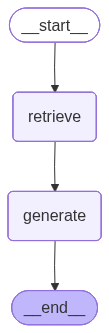

In [13]:
# 그래프 시각화
from IPython.display import Image, display

try:
    display(Image(rag_chain.get_graph().draw_mermaid_png()))
except Exception:
    print(rag_chain.get_graph().draw_mermaid())

## 4. 테스트 (5개 쿼리)

In [14]:
QUERIES = [
    "유형자산의 감가상각 방법에는 어떤 것들이 있나요?",
    "금융자산의 기대신용손실은 어떻게 측정하나요?",
    "수행의무를 식별하고 거래가격을 배분하는 기준은?",
    "사용권자산과 리스부채의 최초 측정 방법은?",
    "연결재무제표 작성 시 지배력 판단 기준은?",
]

In [ ]:
result = rag_chain.invoke({"query": QUERIES[0]})
result

In [ ]:
client.close()
print("Qdrant 연결 종료")